In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
torch.manual_seed(42)

In [4]:
df = pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


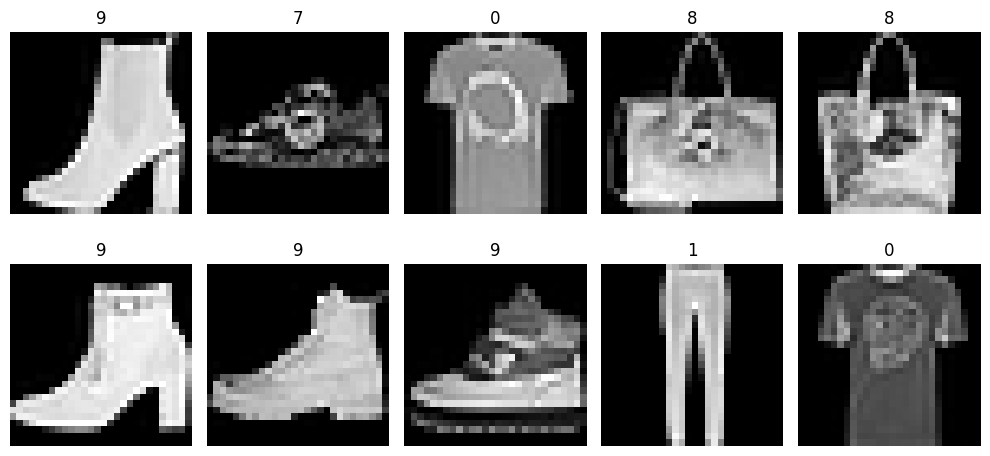

In [5]:
# visualizing image
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    label = df.iloc[i, 0]
    image = df.iloc[i, 1:].values.reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [8]:
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        super().__init__()
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [10]:
train_dataset = CustomDataset(X_train,y_train)

In [11]:
len(train_dataset)

4800

In [12]:
test_dataset = CustomDataset(X_test,y_test)

In [13]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [14]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
         )

    def forward(self,x):
        return self.model(x)

In [15]:
epochs = 100
learning_rate = 0.1

In [16]:
model = MyNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [17]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_feature,batch_labels in train_loader:
        #forward pass
        outputs = model(batch_feature)
        # loss calc
        loss = criterion(outputs,batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grad
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch:{epoch+1}, Loss:{avg_loss}")
        

Epoch:1, Loss:1.321636850833893
Epoch:2, Loss:0.7793365486462911
Epoch:3, Loss:0.6427524626255036
Epoch:4, Loss:0.5751657505830129
Epoch:5, Loss:0.5281801937023799
Epoch:6, Loss:0.4952874955534935
Epoch:7, Loss:0.4602432981133461
Epoch:8, Loss:0.43594589665532113
Epoch:9, Loss:0.41829214711984
Epoch:10, Loss:0.3976178215940793
Epoch:11, Loss:0.3859447174270948
Epoch:12, Loss:0.3714284941057364
Epoch:13, Loss:0.34849797944227856
Epoch:14, Loss:0.34953822041551275
Epoch:15, Loss:0.3174830993016561
Epoch:16, Loss:0.30957285126050316
Epoch:17, Loss:0.2964126534759998
Epoch:18, Loss:0.28544201801220576
Epoch:19, Loss:0.27287159097691377
Epoch:20, Loss:0.26364209145307543
Epoch:21, Loss:0.27335520724455514
Epoch:22, Loss:0.2426882132391135
Epoch:23, Loss:0.24097084249059358
Epoch:24, Loss:0.22358022779226303
Epoch:25, Loss:0.22390356036523978
Epoch:26, Loss:0.2096334281563759
Epoch:27, Loss:0.21853055037558078
Epoch:28, Loss:0.21046126539508503
Epoch:29, Loss:0.18579638224095107
Epoch:30, Lo

In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 83.50%


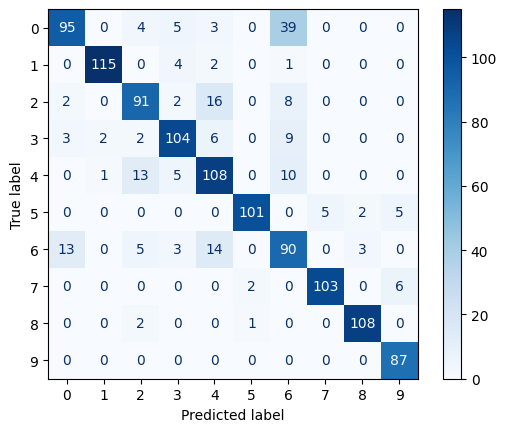

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(batch_labels.numpy())
        y_pred.extend(predicted.numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.65      0.73       146
           1       0.97      0.94      0.96       122
           2       0.78      0.76      0.77       119
           3       0.85      0.83      0.84       126
           4       0.72      0.79      0.76       137
           5       0.97      0.89      0.93       113
           6       0.57      0.70      0.63       128
           7       0.95      0.93      0.94       111
           8       0.96      0.97      0.96       111
           9       0.89      1.00      0.94        87

    accuracy                           0.83      1200
   macro avg       0.85      0.85      0.85      1200
weighted avg       0.84      0.83      0.84      1200

